# Module 02: Data Visualization & Graphical Analysis


## Module outline

* **Step 1: Univariate Visualization**
  * Bar Charts & Pie Charts: Frequency and proportion of qualitative variables.
  * Histograms & Kernel Density Estimate (KDE) Plots: Approximating continuous probability distributions.
  * Box Plots & Strip Plots: Identifying median, skewness, spread, and statistical outliers.
* **Step 2: Bivariate Visualization**
  * Scatter Plots: Mapping relationships, density, and potential non-linearities between two numerical features.
  * Line Plots: Trend discovery, seasonal fluctuations, and temporal tracking.
  * Stacked, Grouped, and Percent Bar Charts: Categorical comparisons.
  * Tools: Foundational rendering in `matplotlib.pyplot` and declarative statistical plotting in `seaborn`.
* **Step 3: Multivariate & Interactive Analysis**
  * Heatmaps: Visualization of Correlation, Covariance, and Confusion Matrices with custom color scales.
  * Pair Plots / Scatter Plot Matrices: Comprehensive grid visualization of all pairwise features.
  * Violin Plots: Merging Box Plots with symmetric KDE curves for deep distribution shape insights.
  * Joint Plots: Combining bivariate scatter displays with marginal distribution graphs.
  * Facet Grids: Conditioned plotting across rows and columns based on categorical variables.
  * Interactive Frameworks: Creating dynamic plots using `plotly` and `bokeh`.


## Example Dataset


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
import numpy as np
import pandas as pd
from IPython.display import display

# Let's define our exact 10-employee dataset in Python to display it cleanly
data = {
    'Employee ID': ['Emp 1', 'Emp 2', 'Emp 3', 'Emp 4', 'Emp 5', 'Emp 6', 'Emp 7', 'Emp 8', 'Emp 9', 'Emp 10'],
    'Department': ['Sales', 'R&D', 'HR', 'R&D', 'Sales', 'R&D', 'HR', 'Sales', 'R&D', 'Sales'],
    'Performance Rating': ['Low', 'Medium', 'Medium', 'High', 'High', 'Low', 'High', 'Medium', 'High', 'Medium'],
    'Years at Company': [1, 3, 2, 5, 4, 1, 8, 3, 10, 3],
    'Monthly Salary': [3000, 4500, 4000, 6000, 5500, 3200, 7000, 4800, 12000, 5000],
    'Attrition (Left?)': ['Yes (1)', 'No (0)', 'No (0)', 'No (0)', 'No (0)', 'Yes (1)', 'No (0)', 'No (0)', 'No (0)', 'Yes (1)']
}

df = pd.DataFrame(data)
display(df)


,Employee ID,Department,Performance Rating,Years at Company,Monthly Salary,Attrition (Left?)
0,Emp 1,Sales,Low,1,3000,Yes (1)
1,Emp 2,R&D,Medium,3,4500,No (0)
2,Emp 3,HR,Medium,2,4000,No (0)
3,Emp 4,R&D,High,5,6000,No (0)
4,Emp 5,Sales,High,4,5500,No (0)
5,Emp 6,R&D,Low,1,3200,Yes (1)
6,Emp 7,HR,High,8,7000,No (0)
7,Emp 8,Sales,Medium,3,4800,No (0)
8,Emp 9,R&D,High,10,12000,No (0)
9,Emp 10,Sales,Medium,3,5000,Yes (1)


## Module 2: Data Visualization & Graphical Analysis

Graphs help us see patterns in the same employee dataset used in Module 1.

### Step 1 — Univariate Visualization

* **Definition:** Analyzing and visualizing the distribution of a **single variable** at a time.
* **Goal:** Understand the range, central tendency, shape, and frequency of a single feature without looking at its relationship with other variables yet.
- **Where we use it:** Inspecting one column, such as Department or Monthly Salary.
- **Why we use it:** To see common values, spread, and unusual observations before comparing columns.


### Module 2: Step 1 — Visualizing Qualitative Data (Bar & Pie Charts)

When dealing with discrete categories (nominal or ordinal data), we want to see the count (frequency) or proportion (percentage) of each category.

1. **Bar Charts**
   * **Definition:** A graph using bar lengths to represent counts or other values for categories.
   * **Where we use it:** Employee counts by department.
   * **Why we use it:** To compare category sizes quickly.
   * **Our Dataset Application:** Visualizing how many employees work in each `Department` (Sales: 4, R&D: 4, HR: 2).

2. **Pie Charts**
   * **Definition:** A circle divided into slices showing shares of one total.
   * **Where we use it:** Department shares when there are only a few categories.
   * **Why we use it:** To show how the whole is divided; all slices together represent 100%.
   * **Our Dataset Application:** Showing the percentage share of each department (Sales: $40\%$, R&D: $40\%$, HR: $20\%$).


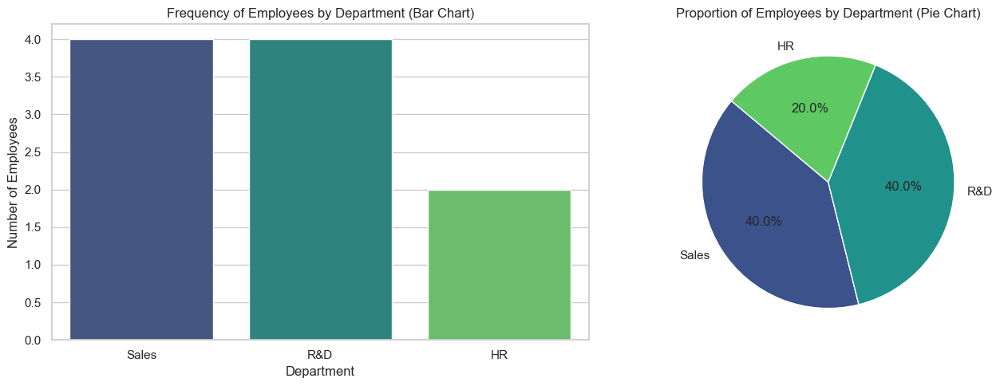

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure a clean aesthetic style
sns.set_theme(style="whitegrid")

# Prepare the figure layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart (Department Counts)
sns.countplot(data=df, x='Department', ax=axes[0], palette='viridis', hue='Department', legend=False)
axes[0].set_title('Frequency of Employees by Department (Bar Chart)')
axes[0].set_ylabel('Number of Employees')
axes[0].set_xlabel('Department')

# 2. Pie Chart (Department Proportion)
dept_counts = df['Department'].value_counts()
axes[1].pie(dept_counts, labels=dept_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', 3), startangle=140)
axes[1].set_title('Proportion of Employees by Department (Pie Chart)')

plt.tight_layout()
plt.show()

### Module 2: Step 1 — Visualizing Continuous Data (Histograms & KDE)

For continuous numerical variables (like `Monthly Salary`), counts of exact values are uninformative because most numbers are unique. Instead, we group values into intervals ("bins") or estimate smooth probability curves.

1. **Histograms**
   * **Definition:** A graph that divides a numerical range into intervals called bins, then counts observations in each bin.
   * **Where we use it:** Salary, age, or measurement distributions.
   * **Why we use it:** To see the shape and concentration of values rather than inspect each number separately.
   * **Our Dataset Application:** Grouping salaries into \$2,000 bins (e.g., \$2,000–\$4,000, \$4,000–\$6,000, etc.).

2. **Kernel Density Estimate (KDE) Plots**
   * **Definition:** A smoothed estimate of a continuous probability density; it need not be bell-shaped.
   * **Where we use it:** Exploring salary or measurement distributions.
   * **Why we use it:** To see a smoother view of the shape than a histogram; the smoothing setting affects the result.

**Reading a KDE:** Probability corresponds to area under the curve over a range, not its height at one point. With only ten salaries, the estimated shape is uncertain.


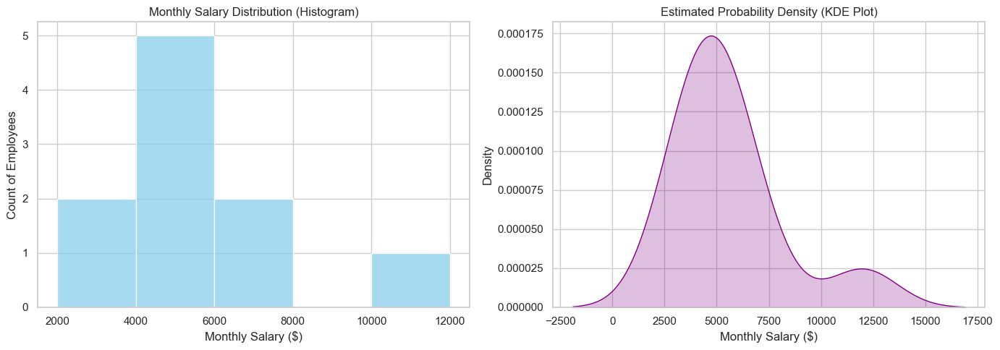

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram (Salary distribution split into bins)
sns.histplot(data=df, x='Monthly Salary', bins=[2000, 4000, 6000, 8000, 10000, 12000], kde=False, color='skyblue', ax=axes[0])
axes[0].set_title('Monthly Salary Distribution (Histogram)')
axes[0].set_xlabel('Monthly Salary ($)')
axes[0].set_ylabel('Count of Employees')

# 2. KDE Plot (Smooth estimated probability density curve)
sns.kdeplot(data=df, x='Monthly Salary', fill=True, color='purple', ax=axes[1])
axes[1].set_title('Estimated Probability Density (KDE Plot)')
axes[1].set_xlabel('Monthly Salary ($)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

### Module 2: Step 1 — Summary Indicators (Box Plots & Strip Plots)

To identify key summary points (like the 5-number summary) and find extreme outliers instantly, we use specialized range plots.

1. **Box Plots**
   * **Definition:** A plot with a box from Q1 to Q3, a median line, whiskers, and separate points for potential outliers.
   * **Where we use it:** Comparing salary centers and spreads.
   * **Why we use it:** To summarize the middle of the data while making unusual values visible.
   * **Our Dataset Application:** Instantly highlighting that **Emp 9** (\$12,000) is an outlier compared to the rest of the group.

2. **Strip Plots**
   * **Definition:** A graph showing each observation as a dot, optionally separated into categories.
   * **Where we use it:** Displaying the individual salaries, especially in a small dataset.
   * **Why we use it:** To keep individual observations visible; jitter moves dots sideways to reduce overlap.

**Box-plot rule:** Whiskers reach the most extreme observations within $1.5\times\text{IQR}$ of the quartiles; they need not reach the minimum and maximum. Points outside are candidates for investigation, not automatically errors. The plotting library uses interpolated quartiles (here Q1 = \$4,125 and Q3 = \$5,875), while the hand-worked Module 1 example uses median-of-halves quartiles.


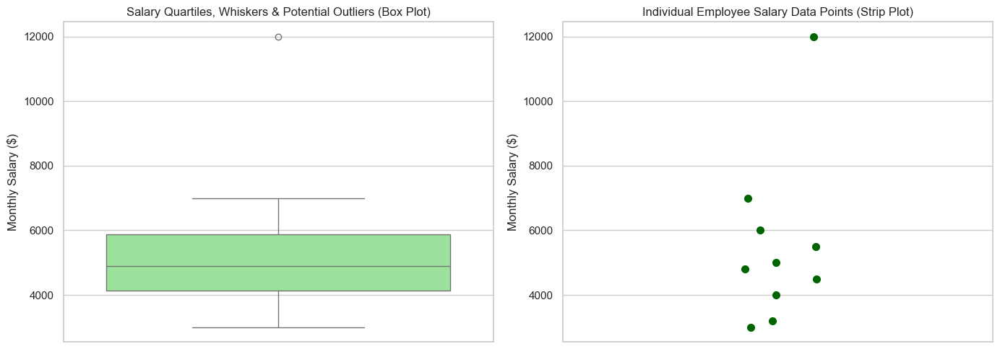

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Box Plot (Visualizing the 5-Number Summary & Outliers)
sns.boxplot(data=df, y='Monthly Salary', color='lightgreen', ax=axes[0])
axes[0].set_title('Salary Quartiles, Whiskers & Potential Outliers (Box Plot)')
axes[0].set_ylabel('Monthly Salary ($)')

# 2. Strip Plot (Showing every individual raw employee salary data point)
sns.stripplot(data=df, y='Monthly Salary', size=8, color='darkgreen', jitter=True, ax=axes[1])
axes[1].set_title('Individual Employee Salary Data Points (Strip Plot)')
axes[1].set_ylabel('Monthly Salary ($)')

plt.tight_layout()
plt.show()

### Module 2: Step 2 — Bivariate Visualization

- **Definition:** Bivariate visualization examines two variables together.
- **Where we use it:** Salary versus tenure, or salary differences across departments.
- **Why we use it:** To see relationships and group differences that one-column plots cannot show.


### Module 2: Step 2 — Scatter Plots & Trend Lines

#### Scatter Plot

- **Definition:** A graph placing each observation at its pair of numerical coordinates $(X,Y)$.
- **Where we use it:** Years at Company on the horizontal axis and Monthly Salary on the vertical axis.
- **Why we use it:** To see the direction, shape, spread, and unusual points in a relationship.
- **Example:** Each dot represents one employee. The salary–tenure Pearson correlation is about 0.95.

#### Trend / Regression Line

- **Definition:** A fitted line summarizing the average linear pattern in a scatter plot.
- **Where we use it:** Summarizing how salary tends to vary with tenure.
- **Why we use it:** To make the overall direction easier to see while keeping the individual points visible.
- **Example:** An upward line shows positive association; it does not prove that staying longer causes a salary increase.


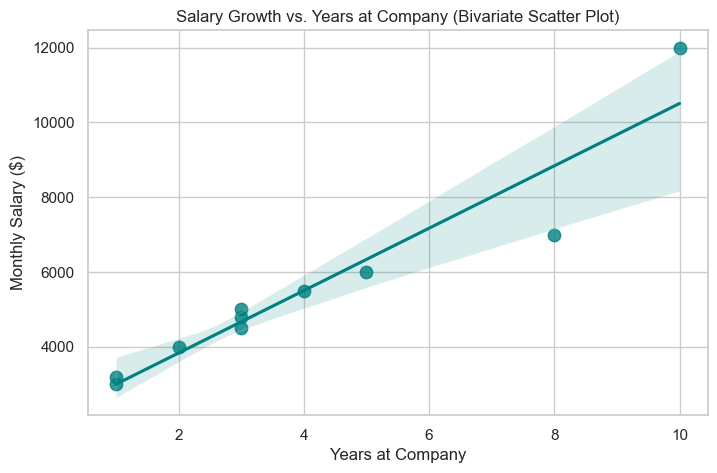

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# Create a scatter plot with a linear regression trend line
sns.regplot(data=df, x='Years at Company', y='Monthly Salary', ax=ax, color='teal', marker='o', scatter_kws={'s': 80})

ax.set_title('Salary Growth vs. Years at Company (Bivariate Scatter Plot)')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Monthly Salary ($)')

plt.show()

### Module 2: Step 2 — Grouped & Stacked Categorical Visuals

When looking at relationships between a categorical variable and a numerical variable, or two categorical variables, standard scatter plots are not ideal. Instead, we group our metrics.

1. **Bivariate Bar Charts (Grouped)**
   * **Definition:** Side-by-side bars showing subgroups within each main category.
   * **Where we use it:** Performance-rating counts within each department.
   * **Why we use it:** To compare the same rating across departments and different ratings within a department.
   * **Our Dataset Application:** Visualizing the frequency of `Performance Ratings` (Low, Medium, High) sub-divided within each `Department`.

2. **Line Plots**
   * **Definition:** A graph joining points in a meaningful order, often time.
   * **Where we use it:** Monthly sales over time, or a descriptive salary-versus-tenure summary.
   * **Why we use it:** To reveal trends across an ordered axis.
   * **Our Dataset Application:** Plotting mean salary at each recorded tenure. These are different employees, so the line is not one employee’s salary history.

**Stacked bars:** Stack subgroup values in one bar to show a total and its composition. A percentage-stacked bar rescales each total to 100% so proportions can be compared. The current code demonstrates grouped bars and a line plot.


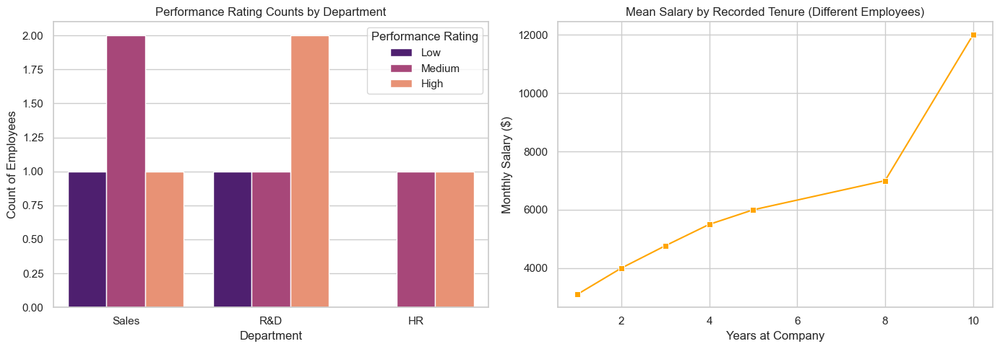

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grouped Count Plot (Performance Ratings by Department)
sns.countplot(data=df, x='Department', hue='Performance Rating', ax=axes[0], palette='magma')
axes[0].set_title('Performance Rating Counts by Department')
axes[0].set_ylabel('Count of Employees')

# 2. Line Plot (Tenure vs. Salary trend)
df_sorted_tenure = df.sort_values('Years at Company')
sns.lineplot(data=df_sorted_tenure, x='Years at Company', y='Monthly Salary', marker='s', errorbar=None, color='orange', ax=axes[1])
axes[1].set_title('Mean Salary by Recorded Tenure (Different Employees)')
axes[1].set_xlabel('Years at Company')
axes[1].set_ylabel('Monthly Salary ($)')

plt.tight_layout()
plt.show()

### Module 2: Step 3 — Multivariate & Interactive Analysis

- **Definition:** Multivariate visualization examines several variables together; related displays can also combine several views of a two-variable relationship.
- **Where we use it:** Comparing salary and tenure across attrition groups or departments.
- **Why we use it:** To see whether an overall pattern changes when groups are viewed separately.


### Module 2: Step 3 — Correlation Heatmaps & Violin Plots

To view relationships among multiple dimensions at once, we compress high-dimensional metrics into intuitive layouts:

1. **Correlation Heatmaps**
   * **Definition:** A colored grid showing the correlation for each pair of numerical features.
   * **Where we use it:** The 2-by-2 tenure/salary correlation matrix in our example, or larger feature matrices.
   * **Why we use it:** To scan many pairwise linear relationships at once.
   * **Our Dataset Application:** Plotting a 2x2 grid representing the strong correlation ($0.95$) between `Years at Company` and `Monthly Salary`.

2. **Violin Plots**
   * **Definition:** A mirrored density estimate showing a distribution’s shape, often with an inner box or quartile marks.
   * **Where we use it:** Comparing salary distributions across departments.
   * **Why we use it:** To show shape as well as center and spread; the shape is only an estimate.
   * **Our Dataset Application:** Visualizing the probability density of salaries split across our departments.

**Reading these examples:** The heatmap diagonal is 1 because a column correlates with itself. The tenure/salary cells are about 0.95. A violin is wider where estimated density is higher; with only two HR employees, its shape should not be treated as reliable evidence of the population shape.


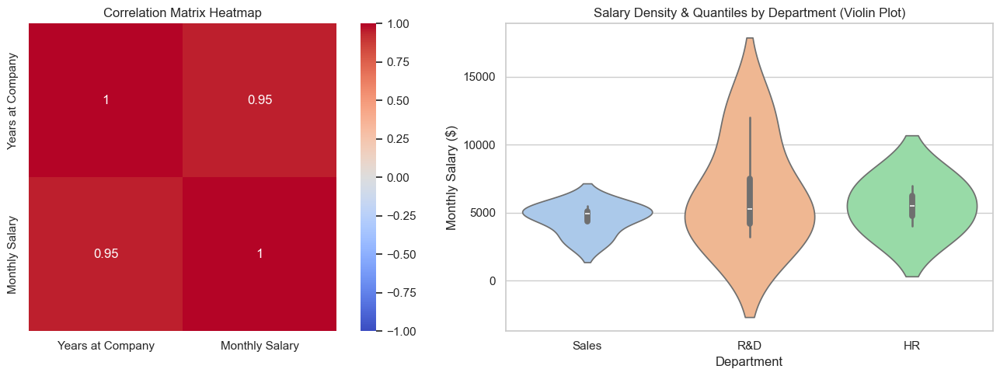

In [7]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Correlation Heatmap (using numerical columns of our 10-employee dataset)
numerical_cols = df[['Years at Company', 'Monthly Salary']]
corr_matrix = numerical_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title('Correlation Matrix Heatmap')

# 2. Violin Plot (Salary distribution per department showing shape & quantiles)
sns.violinplot(data=df, x='Department', y='Monthly Salary', ax=axes[1], palette='pastel', hue='Department', legend=False)
axes[1].set_title('Salary Density & Quantiles by Department (Violin Plot)')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Monthly Salary ($)')

plt.tight_layout()
plt.show()

### Module 2: Step 3 — Pair Plots / Scatter-Plot Matrices

- **Definition:** A grid comparing every pair of selected numerical variables. The diagonal usually shows each variable’s own distribution.
- **Where we use it:** An initial comparison of several numerical features before choosing individual plots.
- **Why we use it:** To spot relationships, groups, and unusual points across multiple pairs in one display.
- **In our dataset:** Compare tenure and salary, coloring employees by whether they left or stayed. The off-diagonal cells repeat the relationship with the axes swapped; the diagonal cells show histograms.


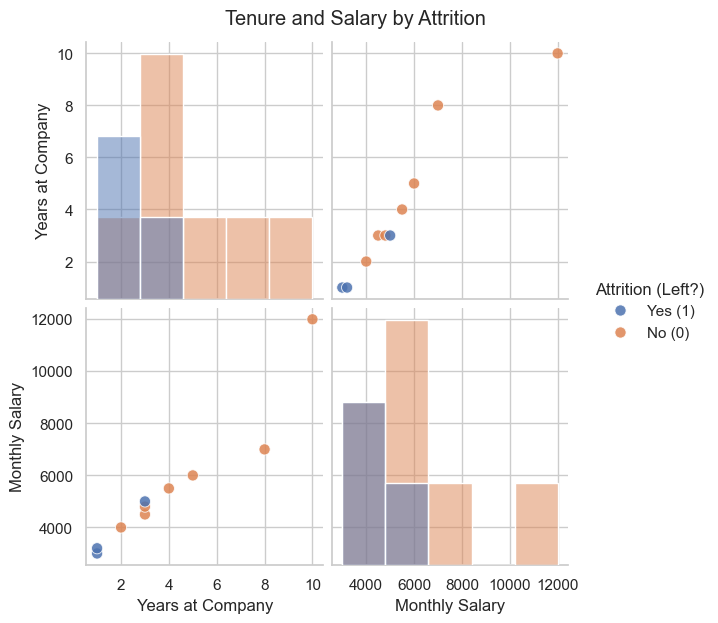

In [8]:
pair_grid = sns.pairplot(
    df, vars=['Years at Company', 'Monthly Salary'], hue='Attrition (Left?)',
    diag_kind='hist', height=3,
    plot_kws={'s':65, 'alpha':0.85}, diag_kws={'bins':5, 'alpha':0.5},
)
pair_grid.fig.suptitle('Tenure and Salary by Attrition', y=1.03)
plt.show()


**What this graph shows:** Salary and tenure tend to rise together in this sample. Color lets us inspect how the attrition groups are positioned. The diagonal histograms show each column separately. With ten employees, apparent group differences are exploratory rather than reliable population conclusions.


### Module 2: Step 3 — Conditioned Plotting (Facet Grids & Joint Displays)

When we want to see how relationships change depending on other categorical factors, we slice our canvas:

1. **Joint Plots**
   * **Definition:** A graph of two variables with each variable’s own distribution displayed along the margins.
   * **Where we use it:** Salary versus tenure with marginal histograms.
   * **Why we use it:** To read the relationship and the separate distributions together.

2. **Facet Grids**
   * **Definition:** A grid of similar plots, each using a different category or subgroup.
   * **Where we use it:** Separate salary-versus-tenure scatter plots for employees who left and stayed.
   * **Why we use it:** To compare patterns across groups using the same plot structure.
   * **Our Dataset Application:** Creating separate scatter plots of `Years at Company` vs `Monthly Salary` for employees who left vs. those who stayed (`Attrition`).


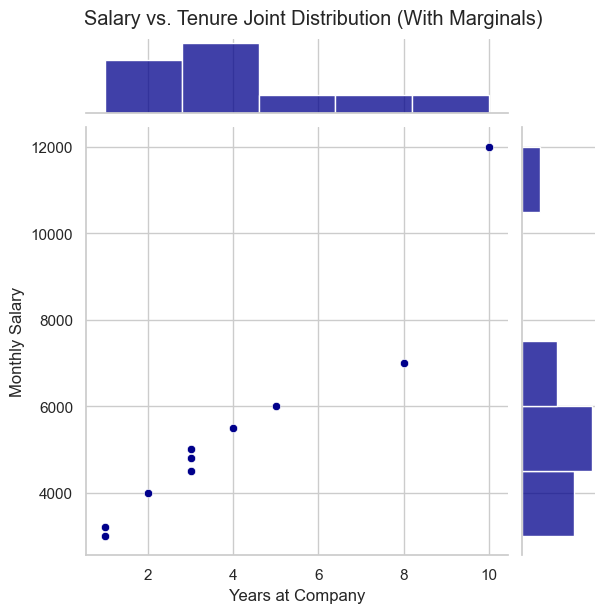

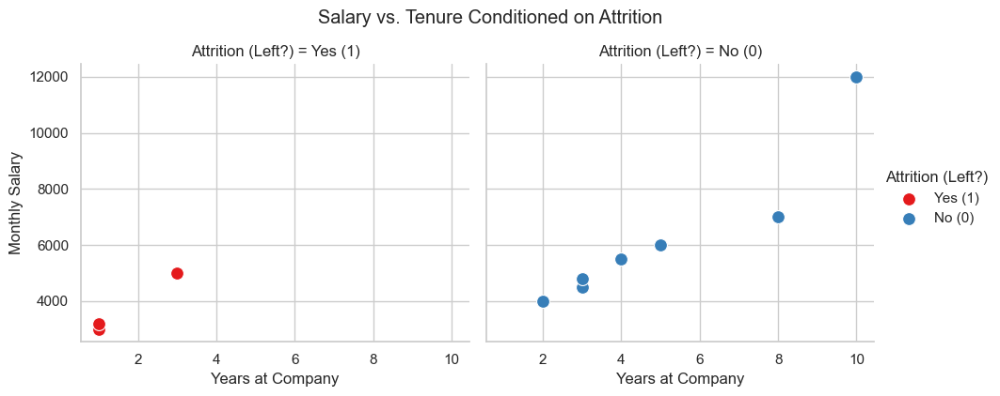

In [9]:
# 1. Joint Plot displaying marginal distributions
g = sns.jointplot(data=df, x='Years at Company', y='Monthly Salary', kind='scatter', color='darkblue', height=6)
g.fig.suptitle('Salary vs. Tenure Joint Distribution (With Marginals)', y=1.02)
plt.show()

# 2. Facet Grid conditioning on Attrition
fg = sns.FacetGrid(df, col='Attrition (Left?)', height=4, aspect=1.2, hue='Attrition (Left?)', palette='Set1')
fg.map(sns.scatterplot, 'Years at Company', 'Monthly Salary', s=100)
fg.add_legend()
fg.fig.suptitle('Salary vs. Tenure Conditioned on Attrition', y=1.05)
plt.show()

### Module 2: Step 3 — Interactive Visualization Frameworks

- **Definition:** Interactive graphs respond to actions such as hovering, zooming, selecting groups, or moving a slider.
- **Where we use them:** Exploring individual observations, comparing subgroups, and presenting data in browser-based reports.
- **Why we use them:** One graph can reveal details and several views without creating a separate static image for every question.

| Framework | Main tools in these examples | Learning purpose |
|---|---|---|
| Plotly | Hover labels, zoom, legend, dropdown | Inspect employees and compare departments |
| Bokeh | Hover labels, zoom, data source, slider and callback | Change the visible data in response to a control |

Hover shows the values behind a point. Zoom changes the visible region, not the data. Filtering changes which observations are displayed, so conclusions must account for what has been excluded.


#### Plotly — Hover, Zoom, and Department Filtering

- **Definition:** Plotly is a Python visualization library that produces interactive browser-based charts.
- **Where we use it:** Exploratory graphs and interactive reports with detailed point labels.
- **Why we use it:** Students can inspect the same salary–tenure relationship at both the overall and individual-employee levels.
- **Code concepts:** A **trace** is one series of plotted data. Here each department has one trace. `hovertemplate` sets the tooltip, and the dropdown updates which traces are visible.
- **Interaction:** Hover over an employee, select a department from the dropdown, drag to zoom, and double-click to reset. Legend clicks can hide or show a department too.

Reference: [Plotly interactive HTML export](https://plotly.com/python/interactive-html-export/).


In [10]:
from pathlib import Path
import plotly.graph_objects as go
from IPython.display import HTML, FileLink, display

visual_dir = Path('visuals')
visual_dir.mkdir(exist_ok=True)
departments = sorted(df['Department'].unique())
plotly_fig = go.Figure()
for department in departments:
    group = df[df['Department'] == department]
    plotly_fig.add_trace(go.Scatter(
        x=group['Years at Company'], y=group['Monthly Salary'], mode='markers',
        name=department, marker={'size':12},
        customdata=group[['Employee ID', 'Attrition (Left?)']].to_numpy(),
        hovertemplate='<b>%{customdata[0]}</b><br>Tenure: %{x} years<br>Salary: $%{y:,.0f}<br>Attrition: %{customdata[1]}<extra>%{fullData.name}</extra>',
    ))
buttons = [dict(label='All departments', method='update', args=[{'visible':[True]*len(departments)}])]
for index, department in enumerate(departments):
    buttons.append(dict(label=department, method='update',
                        args=[{'visible':[i == index for i in range(len(departments))]}]))
plotly_fig.update_layout(
    title='Salary and Tenure — Explore Departments', template='plotly_white', height=480,
    xaxis_title='Years at Company', yaxis_title='Monthly Salary ($)',
    xaxis={'range':[0, 11]}, yaxis={'range':[2000, 13000]},
    updatemenus=[dict(buttons=buttons, direction='down', x=0, y=1.18, xanchor='left')],
    margin={'t':110}, legend_title_text='Department',
)
plotly_html = visual_dir / 'plotly_departments.html'
plotly_fig.write_html(plotly_html, include_plotlyjs=True, full_html=True, auto_open=False)
display(HTML(plotly_fig.to_html(include_plotlyjs=True, full_html=False)))
display(FileLink(str(plotly_html), result_html_prefix='Interactive graph: '))


C:\Users\91832\Desktop\ML-Learning\modules\visuals\plotly_departments.html

**What this graph shows:** The overall relationship can be explored department by department. Hover identifies the \$12,000 employee rather than leaving it as an anonymous point. Fixed axis ranges make group views comparable. A trend within a department may differ from the trend across all employees; filtering does not create more evidence.


#### Bokeh — Filtering with a Slider

- **Definition:** Bokeh creates interactive graphs using data sources, plotting tools, and controls such as sliders.
- **Where we use it:** Explorations where a control changes the data shown in the chart.
- **Why we use it:** To investigate a question such as “What salaries do we see among employees with at least this much tenure?”
- **Code concepts:** `ColumnDataSource` holds equal-length data columns. A `Slider` selects minimum tenure. `CustomJS` responds to a slider change by updating the plotted data in the browser.
- **Interaction:** Move the minimum-tenure slider from 1 to 5. Hover over the remaining points to inspect them; reset the slider to 1 to restore all ten employees.

The browser callback performs this filtering without a running Python server. More complex interactions that run Python calculations can use a Bokeh server.

Reference: [Bokeh notebook visualizations](https://docs.bokeh.org/en/latest/docs/user_guide/output/jupyter.html).


In [11]:
from bokeh.embed import file_html
from bokeh.io import output_notebook, show
from bokeh.layouts import column
from bokeh.models import ColumnDataSource, CustomJS, HoverTool, Slider, Div
from bokeh.plotting import figure
from bokeh.resources import INLINE

employee_data = dict(
    tenure=df['Years at Company'].tolist(), salary=df['Monthly Salary'].tolist(),
    employee=df['Employee ID'].tolist(), department=df['Department'].tolist(),
    attrition=df['Attrition (Left?)'].tolist(),
)
all_employees = ColumnDataSource(data={key:list(values) for key, values in employee_data.items()})
visible_employees = ColumnDataSource(data={key:list(values) for key, values in employee_data.items()})
bokeh_plot = figure(
    title='Salary and Tenure — Minimum Tenure Filter', width=780, height=420,
    x_axis_label='Years at Company', y_axis_label='Monthly Salary ($)',
    x_range=(0, 11), y_range=(2000, 13000), tools='pan,wheel_zoom,box_zoom,reset,save',
)
bokeh_plot.scatter('tenure', 'salary', source=visible_employees, size=12, color='#2563eb', alpha=0.85)
bokeh_plot.add_tools(HoverTool(tooltips=[
    ('Employee', '@employee'), ('Department', '@department'), ('Tenure', '@tenure years'),
    ('Salary', '@salary{$0,0}'), ('Attrition', '@attrition'),
]))
tenure_slider = Slider(start=1, end=10, value=1, step=1, title='Minimum years at company', name='tenure_filter')
visible_count = Div(text='Showing 10 of 10 employees', name='visible_count')
filter_callback = CustomJS(args=dict(full=all_employees, shown=visible_employees, count=visible_count), code="""
    const selected = {};
    for (const key of Object.keys(full.data)) selected[key] = [];
    for (let i = 0; i < full.data.tenure.length; i++) {
        if (full.data.tenure[i] >= cb_obj.value) {
            for (const key of Object.keys(selected)) selected[key].push(full.data[key][i]);
        }
    }
    shown.data = selected;
    count.text = `Showing ${selected.tenure.length} of ${full.data.tenure.length} employees`;
    shown.change.emit();
""")
tenure_slider.js_on_change('value', filter_callback)
bokeh_layout = column(tenure_slider, visible_count, bokeh_plot)
bokeh_html = visual_dir / 'bokeh_tenure_filter.html'
output_notebook(resources=INLINE, hide_banner=True)
show(bokeh_layout)
bokeh_html.write_text(file_html(bokeh_layout, INLINE, 'Employee Tenure Filter'), encoding='utf-8')
display(FileLink(str(bokeh_html), result_html_prefix='Interactive graph: '))


C:\Users\91832\Desktop\ML-Learning\modules\visuals\bokeh_tenure_filter.html

**What this graph shows:** At minimum tenure 5, only three employees remain, with tenure 5, 8, and 10 years. Moving the slider changes the displayed subset, not their salary values. The count makes the shrinking sample visible, and the fixed axes prevent the apparent scale from changing between views.
